In [41]:
import keras
from keras import layers
from tensorflow import data as tf_data
import os
import matplotlib.pyplot as plt
import numpy as np

In [9]:
for folder_name in ('Cat', 'Dog'):
    max_images = 100
    folder_path = os.path.join('PetImages', folder_name)
    num_skipped = 0
    for image_i, fname in enumerate(os.listdir(folder_path)):
        fpath=os.path.join(folder_path, fname)
        try:
            fobj=open(fpath, 'rb')
            is_jfif=b'JFIF' in fobj.peek(10)
        finally:
            fobj.close()

        if image_i > max_images or not is_jfif:
            num_skipped += 1
            os.remove(fpath)

print(num_skipped)

12411


In [44]:
image_size=(224,224)
batch_size=10
train_ds, val_ds = keras.utils.image_dataset_from_directory('PetImages', validation_split=0.2, subset='both', seed=1111)

Found 187 files belonging to 2 classes.
Using 150 files for training.
Using 37 files for validation.


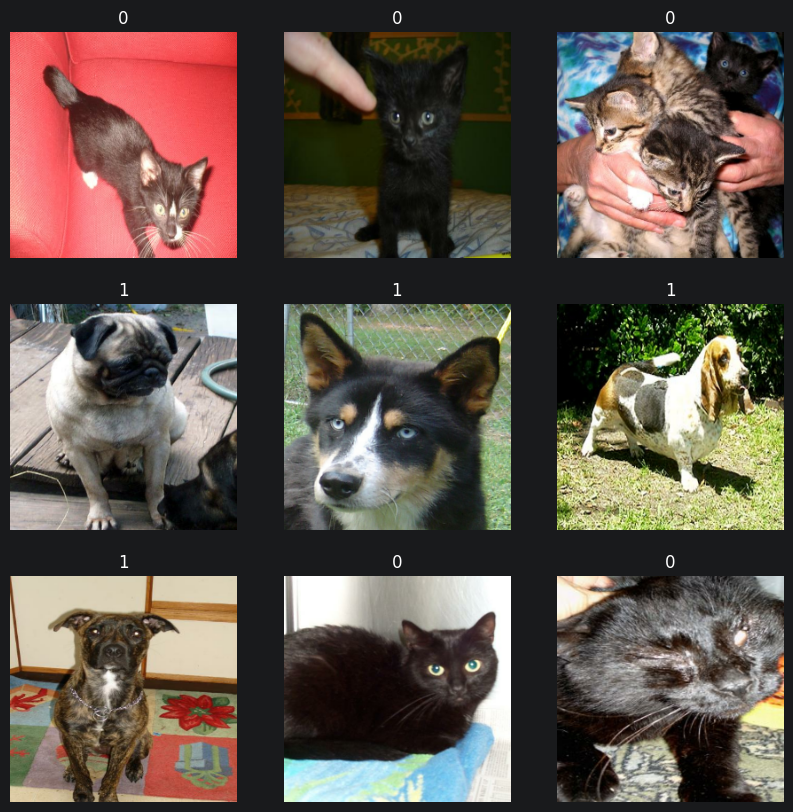

In [24]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3, i+1)
        plt.imshow(np.array(images[i]).astype('uint8'))
        plt.title(int(labels[i]))
        plt.axis('off')

In [32]:
data_augmentation_layers=[layers.RandomFlip('horizontal'),
                          layers.RandomRotation(0.1)]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images=layer(images)
    return images

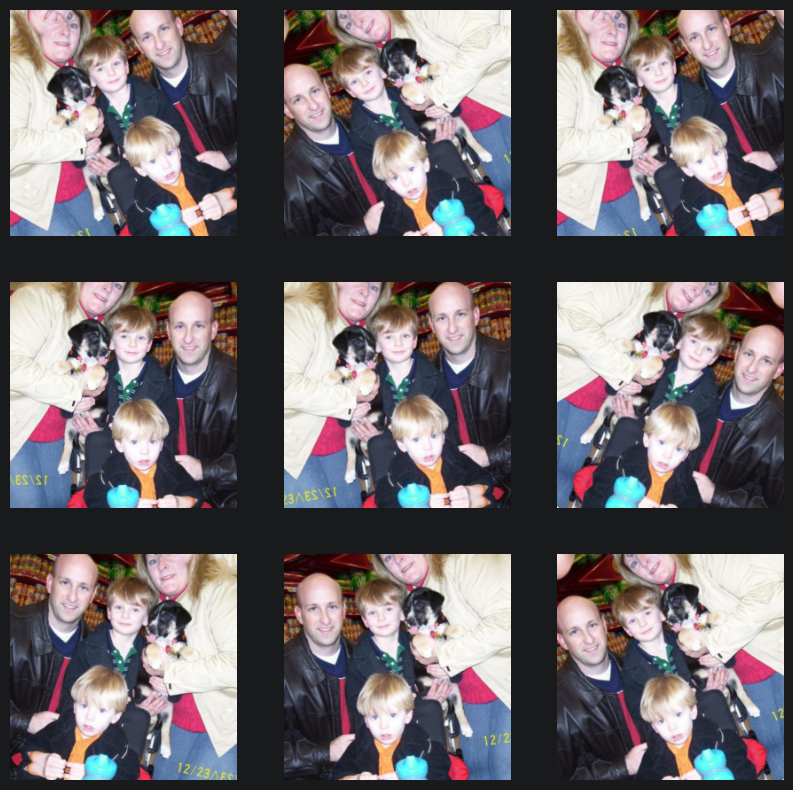

In [35]:
plt.figure(figsize=(10,10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images=data_augmentation(images)
        ax = plt.subplot(3,3, i+1)
        plt.imshow(np.array(augmented_images[0]).astype('uint8'))
        plt.axis('off')

In [45]:
train_ds = train_ds.map(lambda img, label: (data_augmentation(img), label),
                        num_parallel_calls=tf_data.AUTOTUNE)

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)